# 1. Clustering en Aprendizaje No Supervisado

## 1.1 Índice
- **1.1** Índice  
- **1.2** Importación de Librerías y Herramientas Básicas
- **1.3** (Aquí irá el siguiente tema que pase el usuario)

---

## 1.2 Importación de Librerías y Herramientas Básicas


### Librerías Importadas:

- **make_blobs**:
  - Pertenece a `scikit-learn`.
  - Genera datasets sintéticos con múltiples agrupaciones o **clusters**.
  - Facilita la evaluación de algoritmos de clustering como K-means, proporcionando datos controlados y personalizables.

- **NumPy**:
  - Biblioteca especializada en la manipulación de arrays y operaciones matemáticas.
  - Útil para gestionar los datos numéricos generados por `make_blobs` y realizar cálculos eficientes en el entorno Python.

- **Matplotlib**:
  - Herramienta de visualización de datos.
  - Permite representar los clusters generados mediante gráficos, lo cual es crucial para identificar agrupaciones visualmente y validar el comportamiento del algoritmo.
  

In [17]:
# Importamos las librerías necesarias
from sklearn.datasets import make_blobs  # Genera datasets tipo "blobs"
import numpy as np  # Manipulación de arrays y operaciones matemáticas
import matplotlib.pyplot as plt  # Para la visualización de los datos

## 1.3 Variables Configurables

### Descripción General
Este bloque define las **variables configurables** que controlan los parámetros del dataset que se generará para los experimentos de clustering. Estas variables permiten ajustar el comportamiento del conjunto de datos de manera flexible para adaptarse a diferentes escenarios de análisis.

### Explicación de las Variables

- **N_CENTERS**:
  - Número de clusters que se generarán, seleccionado aleatoriamente entre **1 y 10**.
  - Controla cuántos grupos o agrupaciones tendrá el conjunto de datos.
  - Uso de `np.random.randint` garantiza que el valor cambie en cada ejecución, a menos que se use una semilla fija.

- **N_SAMPLES**:
  - Número total de **puntos de datos** o muestras que compondrán el dataset.
  - Un número más alto permite probar la escalabilidad del algoritmo de clustering.

- **COORDINATE_RANGE**:
  - Rango dentro del cual se generarán las **coordenadas de los centroides** de los clusters.  
  - En este caso, los centroides estarán dentro del intervalo **[-10, 10]** para ambas dimensiones (x, y).

- **MIN_DISTANCE**:
  - La **distancia mínima** que debe existir entre los centroides generados.
  - Garantiza que los clusters no se sobrepongan demasiado, facilitando una separación clara entre ellos.

- **STD_RANGE**:
  - Rango de **desviación estándar** para los puntos dentro de cada cluster, definido como **[0.4, 1.4]**.
  - Afecta la dispersión de los puntos alrededor del centroide: un valor menor indica un cluster más compacto, mientras que uno mayor indica una mayor dispersión.

- **RANDOM_STATE**:
  - Valor opcional utilizado como **semilla** para asegurar que los resultados sean reproducibles.
  - Si se fija este valor, cada vez que se ejecute el código, los datos generados serán idénticos, útil para depuración y comparaciones.


In [18]:
# Número aleatorio de clusters entre 1 y 10
N_CENTERS = np.random.randint(1, 11)

# Número total de muestras (puntos)
N_SAMPLES = 10000  

# Rango para las coordenadas de los centroides generados [-10, 10]
COORDINATE_RANGE = (-10, 10)  

# Distancia mínima entre los centroides generados
MIN_DISTANCE = 3

# Rango de desviaciones estándar para cada cluster [0.1, 1.0]
STD_RANGE = (0.4, 1.4)

# Semilla para asegurar reproducibilidad (opcional)
RANDOM_STATE = 42  

## 1.4 Funciones

### Explicación de la Función

- **`generate_blob_centers`**:
  - **Propósito**: Generar un conjunto de **centroides aleatorios** que estén lo suficientemente separados entre sí.
  - **Parámetros**:
    - `n_centers`: Número de centroides que se desean generar.
    - `min_dist`: Distancia mínima que debe existir entre cada centroide.
    - `coord_range`: Rango de coordenadas donde se generarán los centroides (por ejemplo, entre -10 y 10).
    - `random_state`: Semilla opcional para la reproducibilidad de los resultados.

### Lógica de la Función

1. **Inicialización del Generador Aleatorio**:
   - Se utiliza **`np.random.default_rng`** para crear un generador de números aleatorios, opcionalmente inicializado con una semilla (`random_state`).

2. **Bucle de Generación de Centroides**:
   - La lista `centers` almacena los centroides generados.
   - Mientras no se alcancen los **n_centers** deseados, se sigue generando candidatos.

3. **Generación de un Candidato**:
   - Cada candidato es un punto aleatorio dentro del rango definido por **`coord_range`**.
   - Esto asegura que los centroides estén distribuidos dentro del espacio especificado.

4. **Verificación de Distancia Mínima**:
   - Se verifica que el nuevo candidato esté **suficientemente separado** de los centroides ya generados.
   - La distancia entre puntos se calcula con **`np.linalg.norm`**, que mide la norma Euclidiana entre dos puntos.

5. **Agregado del Candidato**:
   - Si el candidato cumple con la condición de separación mínima, se añade a la lista de centroides.

6. **Conversión a Array de NumPy**:
   - Una vez completada la lista, se convierte en un **array de NumPy** para facilitar operaciones posteriores.

In [19]:
def generate_blob_centers(n_centers, min_dist, coord_range, random_state=None):
    """
    Genera 'n_centers' centroides aleatorios separados por al menos 'min_dist'.
    """
    rng = np.random.default_rng(random_state)  # Inicializamos el generador aleatorio
    centers = []  # Lista vacía para los centroides

    while len(centers) < n_centers:  # Continuamos hasta tener la cantidad deseada
        # Genera un candidato dentro del rango especificado
        candidate = rng.uniform(coord_range[0], coord_range[1], size=2)
        
        # Verificamos que el candidato esté suficientemente separado de los demás
        if all(np.linalg.norm(candidate - np.array(c)) >= min_dist for c in centers):
            centers.append(candidate)  # Añadimos el candidato a la lista

    return np.array(centers)  # Convertimos la lista a un array de Numpy

## 1.5 Generación de Datos

### Explicación del Bloque

1. **Generación de Desviaciones Estándar**:
   - Se utiliza `np.random.uniform` para generar **valores aleatorios** dentro del rango especificado en **`STD_RANGE`** para cada cluster.
   - Cada cluster tiene una desviación estándar diferente, lo que hace que algunos clusters sean más compactos y otros más dispersos.

2. **Generación de los Centros de los Clusters**:
   - La función `generate_blob_centers` se usa para **crear los centroides** de los clusters.
   - Los centroides estarán separados por al menos la distancia definida en **`MIN_DISTANCE`** y dentro del rango de coordenadas **`COORDINATE_RANGE`**.

3. **Generación del Dataset**:
   - Se utiliza `make_blobs` de **`scikit-learn`** para generar el conjunto de datos.
   - Parámetros principales:
     - `n_samples`: Número total de puntos o muestras.
     - `centers`: Los centros de los clusters, generados previamente.
     - `cluster_std`: Desviación estándar específica para cada cluster.
     - `random_state`: Semilla utilizada para asegurar que los datos generados sean **reproducibles**.

4. **Impresión de Información**:
   - Se imprimen los **resultados generados** para verificar la cantidad de clusters, los centros y las desviaciones estándar correspondientes.


In [20]:
# Generamos las desviaciones estándar aleatorias para cada cluster
blob_std = np.random.uniform(STD_RANGE[0], STD_RANGE[1], size=N_CENTERS)

# Generamos los centros de los clusters separados por MIN_DISTANCE unidades
blob_centers = generate_blob_centers(N_CENTERS, MIN_DISTANCE, COORDINATE_RANGE, RANDOM_STATE)

# Generamos el dataset con los parámetros configurados
X, y = make_blobs(
    n_samples=N_SAMPLES,  # Número de muestras
    centers=blob_centers,  # Centros de los clusters
    cluster_std=blob_std,  # Desviación estándar de cada cluster
    random_state=RANDOM_STATE  # Semilla para reproducibilidad
)

# Imprimimos la información generada para validar los resultados
print(f"Número de clusters generados: {N_CENTERS}")
print(f"Centros:\n{blob_centers}")
print(f"Desviaciones estándar por cluster:\n{blob_std}")

Número de clusters generados: 6
Centros:
[[ 5.47912097 -1.2224312 ]
 [ 7.1719584   3.94736058]
 [-8.11645304  9.51244703]
 [-7.43772735 -0.99228124]
 [-2.58403952  8.53529978]
 [ 2.8773024   6.45523227]]
Desviaciones estándar por cluster:
[1.35392924 0.91543162 1.25139973 1.22900415 1.38767511 1.09082232]


## 1.6 Visualización
### Explicación del Bloque

1. **Visualización de los Puntos del Dataset**:
   - Se utiliza `plt.scatter` para dibujar cada punto del dataset.
   - Parámetros:
     - **`X[:, 0]` y `X[:, 1]`**: Coordenadas de cada punto en los ejes X e Y.
     - **`c=y`**: Cada cluster recibe un color distinto, diferenciando los grupos.
     - **`cmap='viridis'`**: Colores extraídos del colormap `'viridis'` para una mejor diferenciación.
     - **`marker='o'` y `s=1`**: Cada punto se dibuja como un círculo pequeño.

2. **Dibujo de los Centros de los Clusters**:
   - Los centros de los clusters se destacan utilizando otro gráfico de dispersión con **marcadores rojos**.
   - Parámetros:
     - **`c='red'`**: Color rojo para diferenciar los centros.
     - **`marker='x'` y `s=100`**: Los centros se marcan con una 'x' de mayor tamaño.

3. **Título de la Gráfica**:
   - Se añade un título dinámico utilizando `plt.title`, que indica el **número de clusters generados**.

4. **Mostrar la Gráfica**:
   - Finalmente, se utiliza `plt.show()` para **visualizar el gráfico** en pantalla.



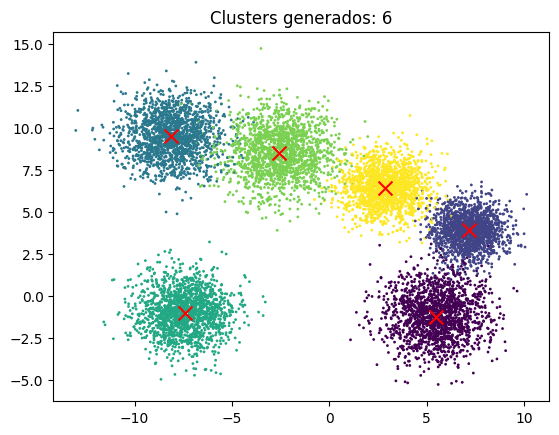

In [21]:
# Dibujamos los puntos del dataset con un mapa de colores para diferenciar clusters
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', marker='o', s=1)

# Dibujamos los centros de los clusters en color rojo con una 'x'
plt.scatter(blob_centers[:, 0], blob_centers[:, 1], c='red', marker='x', s=100)

# Añadimos título indicando el número de clusters generados
plt.title(f"Clusters generados: {N_CENTERS}")

# Mostramos la gráfica
plt.show()

## 1.7 Clustering con K-means
### Explicación del Bloque

1. **Uso del Número de Clusters Generado**:
   - Se utiliza el valor de `N_CENTERS` como el número de clusters (`K`) para el modelo K-means.
   - Esto asegura que el número de clusters del dataset coincida con el número de clusters en el modelo.

2. **Creación del Modelo K-means**:
   - Se crea una instancia del modelo **KMeans**.
   - **Parámetros principales**:
     - `n_clusters`: Número de clusters que debe identificar el algoritmo.
     - `random_state`: Semilla para asegurar reproducibilidad.
     - `n_init=10`: Número de veces que se ejecutará el algoritmo con diferentes inicializaciones para encontrar la mejor solución.

3. **Ajuste del Modelo y Predicciones**:
   - El método `fit_predict`:
     - **Ajusta el modelo** a los datos (`X`).
     - **Asigna etiquetas** a cada punto, indicando a qué cluster pertenece.

4. **Impresión de las Etiquetas Generadas**:
   - Se imprimen las etiquetas asignadas por K-means para validar los resultados.




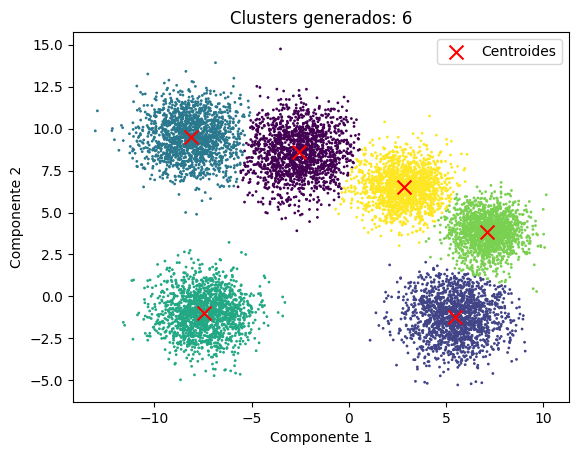

In [22]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Parámetros
K = N_CENTERS  # Número de clusters
RANDOM_STATE = 42  # Semilla para reproducibilidad

# Creamos el modelo K-means
kmeans = KMeans(n_clusters=K, random_state=RANDOM_STATE)

kmeans.fit(X)

# Ajustamos el modelo y obtenemos las predicciones
y_pred = kmeans.fit_predict(X)

# Dibujamos los puntos del dataset con un mapa de colores para diferenciar clusters
plt.scatter(X[:, 0], X[:, 1], c=y_pred, cmap='viridis', marker='o', s=1)

# Dibujamos los centros de los clusters en color rojo con una 'x'
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
            c='red', marker='x', s=100, label='Centroides')

# Añadimos título indicando el número de clusters generados
plt.title(f"Clusters generados: {K}")
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')

# Añadimos leyenda
plt.legend()

# Mostramos la gráfica
plt.show()


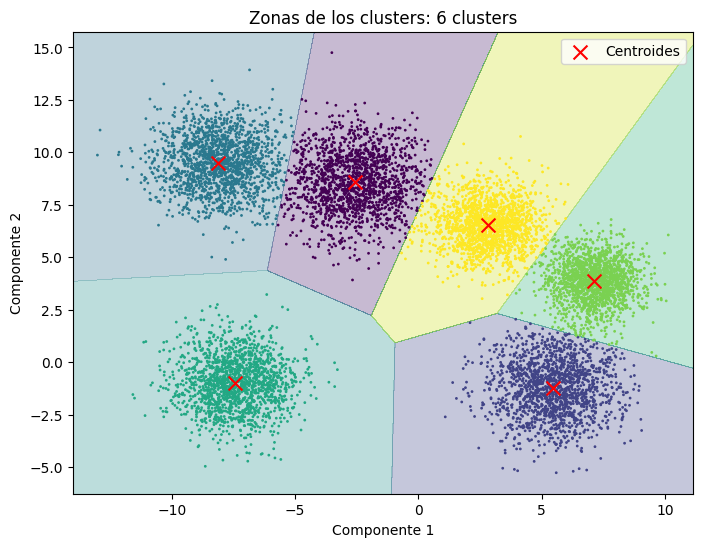

In [23]:
# Crear una malla de puntos para trazar las fronteras
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                    np.arange(y_min, y_max, 0.01))

# Predecir los clusters para cada punto de la malla
Z = kmeans.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Graficar las fronteras de los clusters como contornos
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, cmap='viridis', alpha=0.3)

# Dibujar los puntos originales del dataset
plt.scatter(X[:, 0], X[:, 1], c=y_pred, cmap='viridis', s=1, marker='o')

# Dibujar los centroides
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
            c='red', marker='x', s=100, label='Centroides')

# Personalizar la gráfica
plt.title(f"Zonas de los clusters: {K} clusters")
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.legend()

# Mostrar la gráfica
plt.show()

In [24]:
print(f"Número de clusters generados: {N_CENTERS}")

# Imprimimos la información calculados por K-means
print("Centroides de los clusters:")
print(f"Desviaciones estándar por cluster:\n{kmeans.cluster_centers_}")


# Imprimimos la información generada para validar los resultados
print("Centroides de los clusters Generados:")
print(f"Centros:\n{blob_centers}")

Número de clusters generados: 6
Centroides de los clusters:
Desviaciones estándar por cluster:
[[-2.57423112  8.58162148]
 [ 5.45278804 -1.24404904]
 [-8.11446049  9.51282995]
 [-7.43338385 -0.994662  ]
 [ 7.12265086  3.85217772]
 [ 2.81783786  6.52756647]]
Centroides de los clusters Generados:
Centros:
[[ 5.47912097 -1.2224312 ]
 [ 7.1719584   3.94736058]
 [-8.11645304  9.51244703]
 [-7.43772735 -0.99228124]
 [-2.58403952  8.53529978]
 [ 2.8773024   6.45523227]]


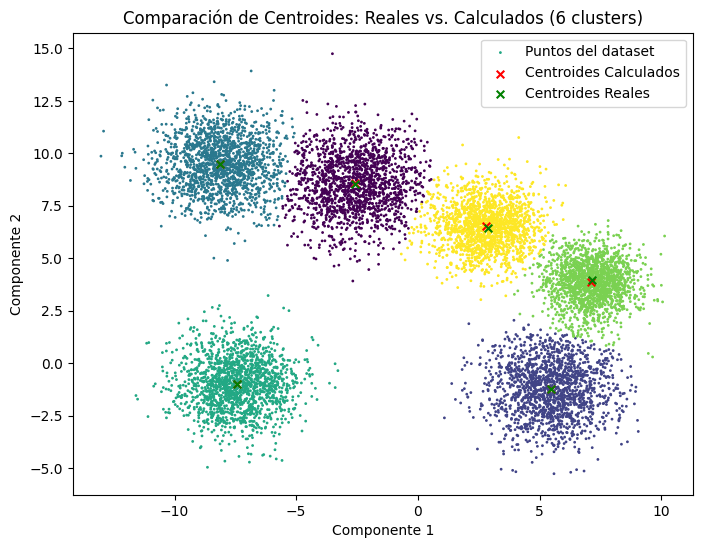

In [25]:
# Graficar los puntos del dataset
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, cmap='viridis', s=1, label='Puntos del dataset')

# Graficar los centroides calculados por K-means
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
            c='red', marker='x', s=30, label='Centroides Calculados')

# Graficar los centroides reales
plt.scatter(blob_centers[:, 0], blob_centers[:, 1], 
            c='green', marker='x', s=30, label='Centroides Reales')

# Añadir título e información relevante
plt.title(f"Comparación de Centroides: Reales vs. Calculados ({K} clusters)")
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.legend()

# Mostrar la gráfica
plt.show()

Distancias a los centroides:
 [[ 7.06713571  6.34482084 11.05834901  8.01393761  7.35953243  5.3328293 ]
 [ 8.62495182  4.06694275 13.41543312 10.85465334  4.51960312  4.53122954]
 [ 5.59783686  9.45841307  8.28098183  5.96759725 10.15845792  6.80374621]
 [ 6.09650711  9.244865    8.67971716  5.64513551 10.21256309  7.07591189]
 [ 4.64462971  8.04842019  9.67894611 10.00417335  6.73918132  2.72218999]]
Cluster asignado a cada punto nuevo: [5 1 0 3 5]


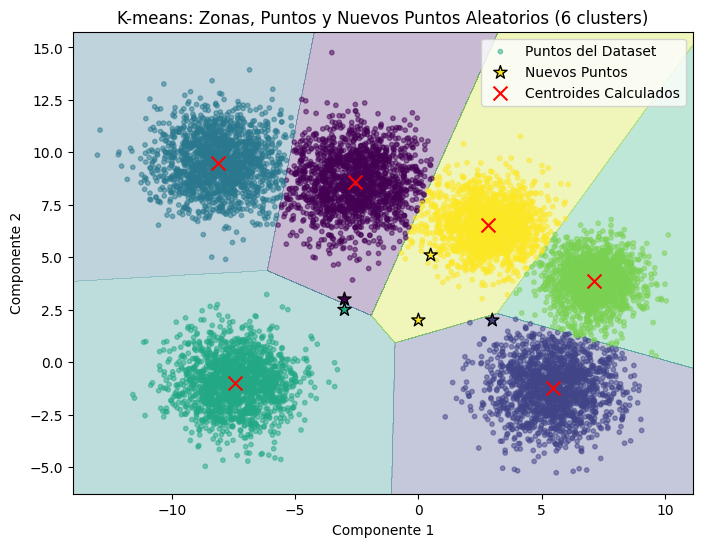

In [26]:
# Generamos un conjunto de puntos aleatorios (X_new) dentro del rango del dataset original
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

# Crear malla de puntos para graficar las zonas
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                    np.arange(y_min, y_max, 0.01))

# Predecir los clusters para cada punto de la malla
Z = kmeans.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Generamos 10 puntos aleatorios para X_new
X_new = np.random.uniform(low=[x_min, y_min], high=[x_max, y_max], size=(10, 2))
# Generamos 10 puntos aleatorios para X_new
X_new = np.array([[0, 2], [3, 2], [-3, 3], [-3, 2.5],[0.5, 5.1]])

# Usar kmeans.transform para calcular distancias a los centroides
distancias = kmeans.transform(X_new)
print("Distancias a los centroides:\n", distancias)

# Predecimos las clases de los puntos aleatorios usando la menor distancia
y_new_pred = np.argmin(distancias, axis=1)
print("Cluster asignado a cada punto nuevo:", y_new_pred)

# Visualización
plt.figure(figsize=(8, 6))

# Graficar las zonas de los clusters
plt.contourf(xx, yy, Z, cmap='viridis', alpha=0.3)

# Graficar los puntos originales con los colores de sus clusters
plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, cmap='viridis', s=10, marker='o', alpha=0.5, label='Puntos del Dataset')

# Graficar los nuevos puntos aleatorios con sus clusters asignados
plt.scatter(X_new[:, 0], X_new[:, 1], c=y_new_pred, cmap='viridis', marker='*', s=100, edgecolors='black', label='Nuevos Puntos')

# Graficar los centroides calculados por K-means
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
            c='red', marker='x', s=100, label='Centroides Calculados')

# Personalización de la gráfica
plt.title(f"K-means: Zonas, Puntos y Nuevos Puntos Aleatorios ({K} clusters)")
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.legend()

# Mostrar la gráfica
plt.show()

Explicación del Código Original
n_clusters=8:
Cada modelo busca dividir los datos en 8 clusters.

init="random":
Inicializa los centroides de forma aleatoria (otra opción común es "k-means++").

n_init=1:
Solo se hace una inicialización del modelo (por defecto, K-means realiza múltiples inicializaciones para evitar malos resultados).

algorithm="lloyd" y "elkan":

"lloyd": Es el algoritmo clásico de K-means, que itera buscando minimizar la varianza dentro de los clusters.
"elkan": Es una versión optimizada para acelerar el cálculo de distancias en datasets grandes.
max_iter:
Define cuántas iteraciones puede realizar el algoritmo antes de detenerse. En este caso, se realizan modelos con 1, 2, 3, y 4 iteraciones, y finalmente un modelo con hasta 2000 iteraciones.

In [27]:
def plot_data(X):
    """Función para graficar los datos."""
    plt.scatter(X[:, 0], X[:, 1], s=1, alpha=0.6, cmap='viridis')

def plot_centroids(centroids, circle_color='r', cross_color='w'):
    """Función para graficar los centroides con círculos y cruces."""
    plt.scatter(centroids[:, 0], centroids[:, 1], 
                marker='o', s=80, linewidths=8, color=circle_color, alpha=0.5)
    plt.scatter(centroids[:, 0], centroids[:, 1], 
                marker='x', s=50, linewidths=2, color=cross_color)

def plot_decision_boundaries(kmeans, X, show_centroids=True, show_xlabels=True, show_ylabels=True):
    """Función para graficar las fronteras de decisión."""
    # Crear una malla de puntos
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))
    
    Z = kmeans.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Dibujar las fronteras de los clusters
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')

    # Graficar los puntos del dataset
    plot_data(X)
    
    # Graficar los centroides si es necesario
    if show_centroids:
        plot_centroids(kmeans.cluster_centers_)

    # Personalizar etiquetas de los ejes
    if not show_xlabels:
        plt.tick_params(labelbottom=False)
    if not show_ylabels:
        plt.tick_params(labelleft=False)


C:\Users\david\AppData\Local\Temp\ipykernel_31500\720046453.py:3: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X[:, 0], X[:, 1], s=1, alpha=0.6, cmap='viridis')
C:\Users\david\AppData\Local\Temp\ipykernel_31500\720046453.py:3: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X[:, 0], X[:, 1], s=1, alpha=0.6, cmap='viridis')
C:\Users\david\AppData\Local\Temp\ipykernel_31500\720046453.py:3: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X[:, 0], X[:, 1], s=1, alpha=0.6, cmap='viridis')
C:\Users\david\AppData\Local\Temp\ipykernel_31500\720046453.py:3: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X[:, 0], X[:, 1], s=1, alpha=0.6, cmap='viridis')
C:\Users\david\AppData\Local\Temp\ipykernel_31500\720046453.py:3: UserWarning: No data for colormapping provided via 'c'

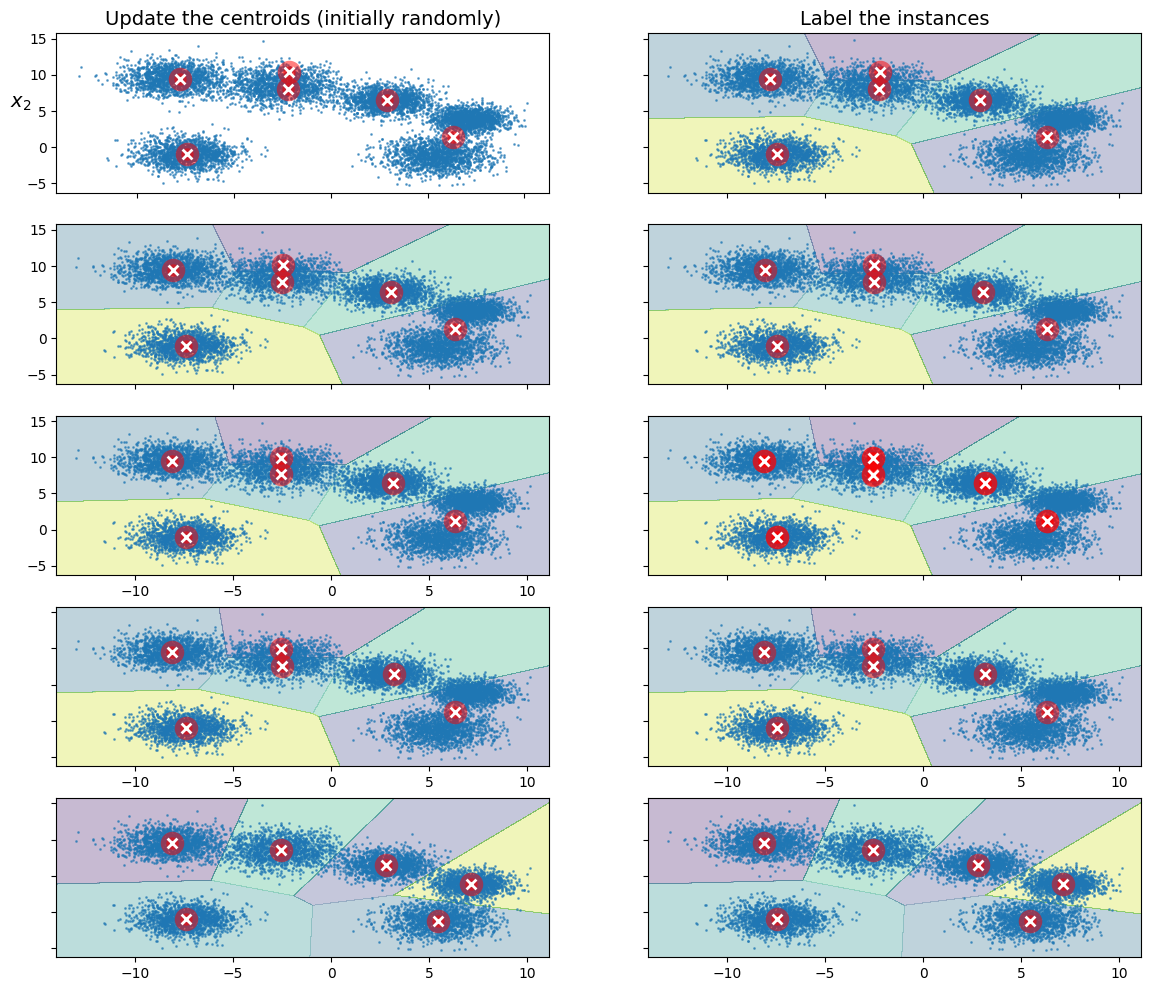

In [28]:
from sklearn.cluster import KMeans

# Configuración del modelo K-means
N_CENTERS = K  # Número de clusters
RANDOM_STATE = 42

# Crear múltiples modelos de K-means con diferentes iteraciones
kmeans_iter1 = KMeans(n_clusters=N_CENTERS, init="random", n_init=1, algorithm="lloyd", max_iter=1, random_state=RANDOM_STATE)
kmeans_iter2 = KMeans(n_clusters=N_CENTERS, init="random", n_init=1, algorithm="lloyd", max_iter=2, random_state=RANDOM_STATE)
kmeans_iter3 = KMeans(n_clusters=N_CENTERS, init="random", n_init=1, algorithm="lloyd", max_iter=3, random_state=RANDOM_STATE)
kmeans_iter4 = KMeans(n_clusters=N_CENTERS, init="random", n_init=1, algorithm="lloyd", max_iter=4, random_state=RANDOM_STATE)
kmeans_iter5 = KMeans(n_clusters=N_CENTERS, init="random", algorithm="elkan", max_iter=2000, random_state=RANDOM_STATE)

# Ajustamos cada modelo al dataset
models = [kmeans_iter1, kmeans_iter2, kmeans_iter3, kmeans_iter4, kmeans_iter5]
for model in models:
    model.fit(X)

# Visualización de los diferentes pasos del algoritmo
plt.figure(figsize=(14, 12))  # Tamaño grande para acomodar 10 subgráficos

# Subgráficos para cada iteración
plt.subplot(521)
plot_data(X)
plot_centroids(kmeans_iter1.cluster_centers_, circle_color='r', cross_color='w')
plt.ylabel("$x_2$", fontsize=14, rotation=0)
plt.tick_params(labelbottom=False)
plt.title("Update the centroids (initially randomly)", fontsize=14)

plt.subplot(522)
plot_decision_boundaries(kmeans_iter1, X, show_xlabels=False, show_ylabels=False)
plt.title("Label the instances", fontsize=14)

plt.subplot(523)
plot_decision_boundaries(kmeans_iter1, X, show_centroids=False, show_xlabels=False)
plot_centroids(kmeans_iter2.cluster_centers_)

plt.subplot(524)
plot_decision_boundaries(kmeans_iter2, X, show_xlabels=False, show_ylabels=False)

plt.subplot(525)
plot_decision_boundaries(kmeans_iter2, X, show_centroids=False)
plot_centroids(kmeans_iter3.cluster_centers_)

plt.subplot(526)
plot_decision_boundaries(kmeans_iter3, X, show_xlabels=False, show_ylabels=False)
plot_centroids(kmeans_iter4.cluster_centers_)

plt.subplot(527)
plot_decision_boundaries(kmeans_iter4, X, show_ylabels=False)

plt.subplot(528)
plot_decision_boundaries(kmeans_iter4, X, show_ylabels=False)

plt.subplot(529)
plot_decision_boundaries(kmeans_iter5, X, show_ylabels=False)

plt.subplot(5, 2, 10)
plot_decision_boundaries(kmeans_iter5, X, show_ylabels=False)

# Mostrar la gráfica final
plt.show()


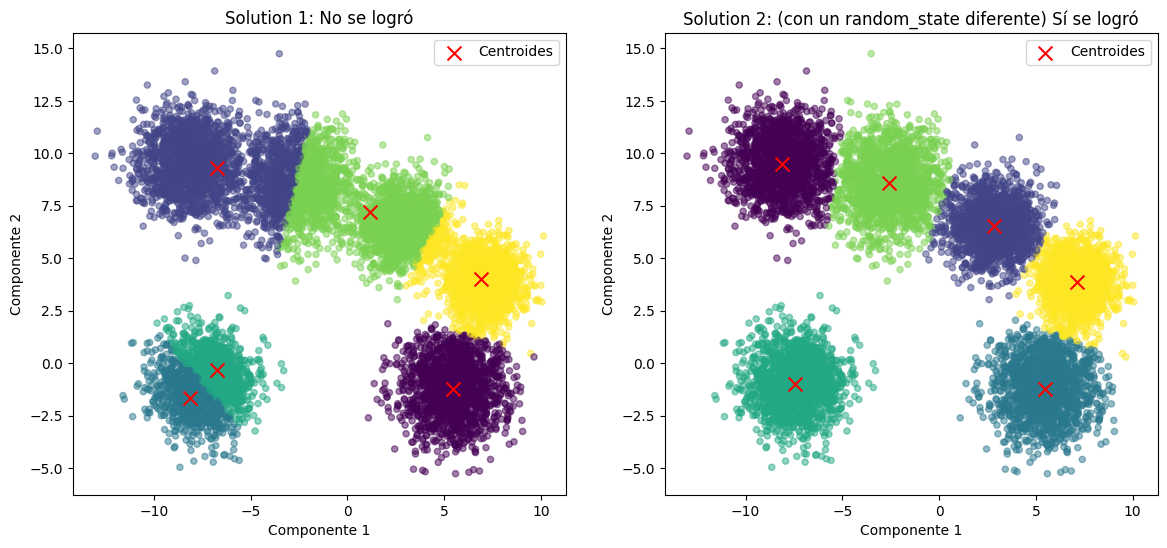

In [29]:


def plot_clusterer_comparison(model1, model2, X, title1, title2):
    """Función para comparar dos modelos K-means con diferentes inicializaciones."""
    
    # Crear la figura con dos subgráficos lado a lado
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Modelo 1: Ajustar y graficar la primera solución
    model1.fit(X)
    axes[0].scatter(X[:, 0], X[:, 1], c=model1.labels_, cmap='viridis', s=20, alpha=0.5)
    axes[0].scatter(model1.cluster_centers_[:, 0], model1.cluster_centers_[:, 1], 
                    c='red', marker='x', s=100, label='Centroides')
    axes[0].set_title(title1)

    # Modelo 2: Ajustar y graficar la segunda solución
    model2.fit(X)
    axes[1].scatter(X[:, 0], X[:, 1], c=model2.labels_, cmap='viridis', s=20, alpha=0.5)
    axes[1].scatter(model2.cluster_centers_[:, 0], model2.cluster_centers_[:, 1], 
                    c='red', marker='x', s=100, label='Centroides')
    axes[1].set_title(title2)

    # Añadir leyenda
    for ax in axes:
        ax.legend()
        ax.set_xlabel("Componente 1")
        ax.set_ylabel("Componente 2")

    # Ajustar la distribución de los subgráficos


# Crear dos modelos K-means con diferentes estados aleatorios
kmeans_rnd_init1 = KMeans(n_clusters=K, init="random", n_init=1, algorithm="lloyd", random_state=11)
kmeans_rnd_init2 = KMeans(n_clusters=K, init="random", algorithm="elkan", max_iter=2000, random_state=42)
# Comparar ambas soluciones usando la función personalizada
plot_clusterer_comparison(
    kmeans_rnd_init1, 
    kmeans_rnd_init2, 
    X, 
    "Solution 1: No se logró", 
    "Solution 2: (con un random_state diferente) Sí se logró"
)

# Mostrar la gráfica comparativa
plt.show()


## Extra


1. Método del Codo (Elbow Method)
Este método evalúa la inercia (suma de distancias cuadradas de cada punto a su centroide más cercano) para diferentes valores de K. El punto donde la disminución de la inercia se vuelve menos pronunciada indica un buen número de clusters

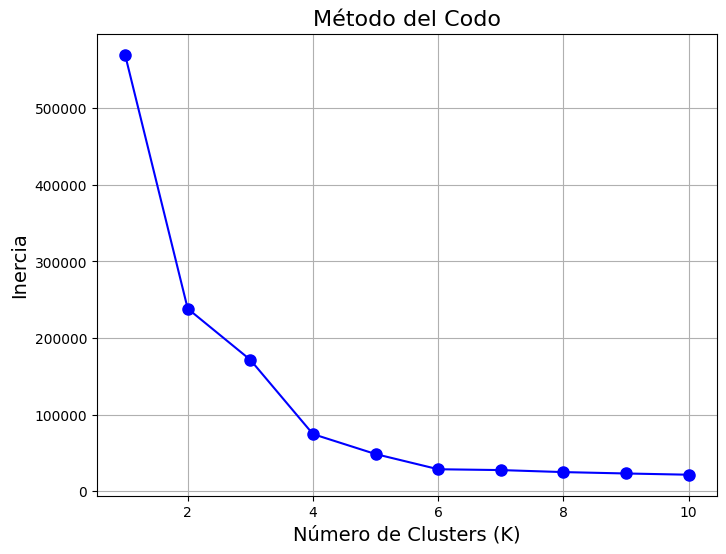

In [30]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# ==============================
# VARIABLES CONFIGURABLES
# ==============================
K_MAX = 10  # Máximo número de clusters a probar

# ==============================
# CÁLCULO DE INERCIA PARA DIFERENTES K
# ==============================
inertias = []  # Lista para almacenar las inercias

for k in range(1, K_MAX + 1):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)  # Ajustamos el modelo
    inertias.append(kmeans.inertia_)  # Guardamos la inercia para este K

# ==============================
# VISUALIZACIÓN DEL MÉTODO DEL CODO
# ==============================
plt.figure(figsize=(8, 6))
plt.plot(range(1, K_MAX + 1), inertias, 'bo-', markersize=8)
plt.xlabel('Número de Clusters (K)', fontsize=14)
plt.ylabel('Inercia', fontsize=14)
plt.title('Método del Codo', fontsize=16)
plt.grid(True)
plt.show()


2. Método Silhouette (Silhouette Score)
Este método mide qué tan bien se agrupan los puntos en un cluster comparado con su distancia a otros clusters. El puntaje oscila entre -1 y 1, donde valores más cercanos a 1 indican una mejor agrupación.

Código del Método Silhouette:

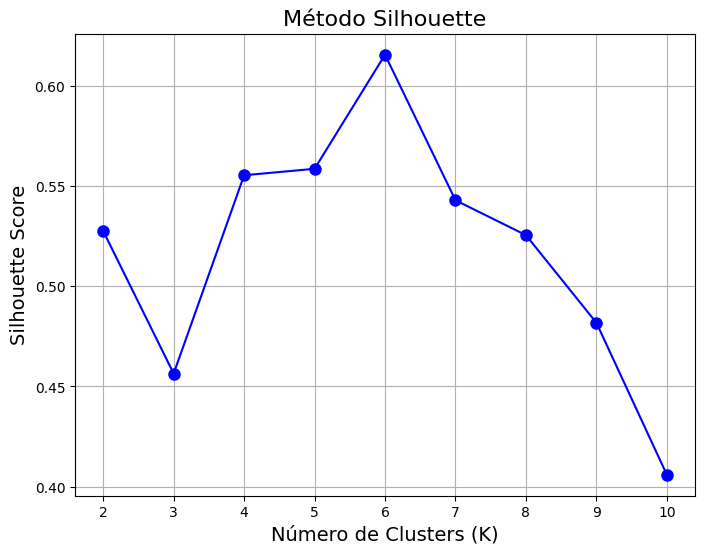

In [31]:
from sklearn.metrics import silhouette_score

# ==============================
# VARIABLES CONFIGURABLES
# ==============================
K_MAX = 10  # Máximo número de clusters a probar

# ==============================
# CÁLCULO DE SILHOUETTE SCORE PARA DIFERENTES K
# ==============================
silhouette_scores = []  # Lista para almacenar los puntajes

for k in range(2, K_MAX + 1):  # El silhouette_score no se define para K=1
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)  # Ajustamos el modelo
    score = silhouette_score(X, kmeans.labels_)  # Calculamos el puntaje
    silhouette_scores.append(score)

# ==============================
# VISUALIZACIÓN DEL MÉTODO SILHOUETTE
# ==============================
plt.figure(figsize=(8, 6))
plt.plot(range(2, K_MAX + 1), silhouette_scores, 'bo-', markersize=8)
plt.xlabel('Número de Clusters (K)', fontsize=14)
plt.ylabel('Silhouette Score', fontsize=14)
plt.title('Método Silhouette', fontsize=16)
plt.grid(True)
plt.show()


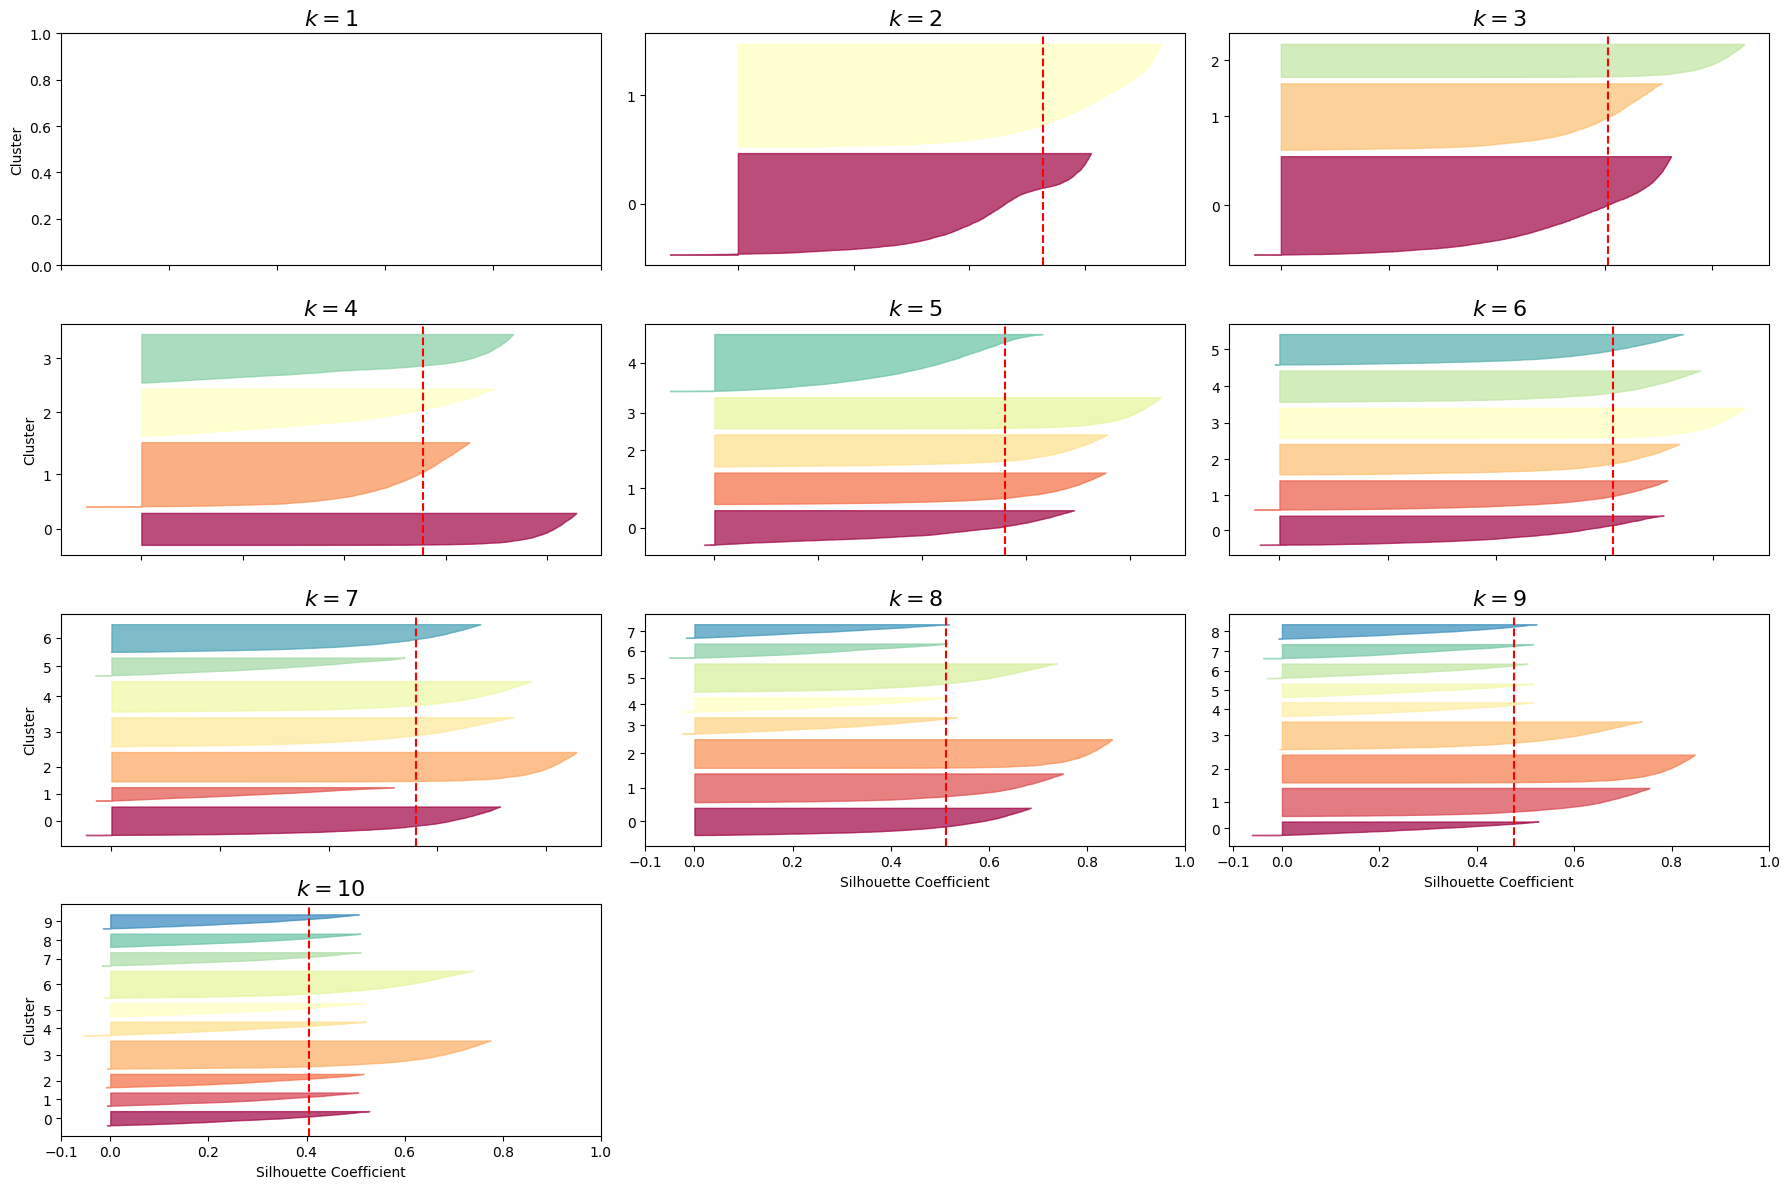

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
from matplotlib.ticker import FixedLocator, FixedFormatter

# Definir el rango de k desde 1 hasta 10
k_values = range(1, 11)

# Crear listas para almacenar los modelos y las puntuaciones de Silhouette
kmeans_per_k = []
silhouette_scores = []

# Ajustar K-means para cada valor de k
for k in k_values:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    kmeans.fit(X)
    kmeans_per_k.append(kmeans)

    # Calcular la puntuación de Silhouette solo si k > 1
    if k > 1:
        score = silhouette_score(X, kmeans.labels_)
    else:
        score = np.nan  # No se define el coeficiente de Silhouette para k=1
    silhouette_scores.append(score)

# Crear la figura para graficar los coeficientes de Silhouette
plt.figure(figsize=(18, 12))  # Ajustamos el tamaño para 10 subgráficos

# Iterar sobre cada valor de k para generar los subgráficos
for k in k_values:
    plt.subplot(4, 3, k)  # Distribución 4 filas x 3 columnas

    # Obtener las etiquetas y los coeficientes de Silhouette si k > 1
    if k > 1:
        y_pred = kmeans_per_k[k - 1].labels_
        silhouette_coefficients = silhouette_samples(X, y_pred)

        # Variables para la disposición de los clusters en la gráfica
        padding = len(X) // 30
        pos = padding
        ticks = []

        # Graficar los coeficientes de Silhouette para cada cluster
        for i in range(k):
            coeffs = silhouette_coefficients[y_pred == i]
            coeffs.sort()

            color = mpl.cm.Spectral(i / k)
            plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                              facecolor=color, edgecolor=color, alpha=0.7)
            ticks.append(pos + len(coeffs) // 2)
            pos += len(coeffs) + padding

        # Configurar las etiquetas del eje Y
        plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
        plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))

    # Configurar etiquetas condicionales
    if k in (1, 4, 7, 10):
        plt.ylabel("Cluster")

    if k in (8, 9, 10):
        plt.gca().set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
        plt.xlabel("Silhouette Coefficient")
    else:
        plt.tick_params(labelbottom=False)

    # Dibujar línea vertical para la media de Silhouette si k > 1
    if k > 1:
        plt.axvline(x=silhouette_scores[k - 1], color="red", linestyle="--")

    # Título para cada subgráfico
    plt.title(f"$k={k}$", fontsize=16)

# Mostrar la gráfica completa
plt.tight_layout()
plt.show()
